# Backtest 001 — Bollinger Squeeze + HMM Regime Filter

**Goal:** Test whether a walk-forward HMM regime filter applied to the Bollinger Squeeze strategy improves Sharpe ratio vs the baseline.

## No-Lookahead Design

The regime label for trading day **t** is determined using only data **strictly before t**:

```
Every month-end T:
  1. Train HMM on features[start : T]  (expanding window)
  2. State at T = model.predict(X_train)[-1]   ← last bar of training set
  3. Regime label applied to days (T, next_month_end]  ← FUTURE trading only
```

Because trading days in month **M+1** use a model trained through month **M**,
there is zero future information in the regime signal.

**Regime filter logic:**  Only allow new entries on days labelled **Bull** or **Neutral**.
Open positions are held to their normal exits regardless of regime shift.

In [22]:
# ── dependencies ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

import vectorbt as vbt
import numba as nb
from numba import njit, prange

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# path for custom indicators
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.trailing_sl import atr_trailing_nb

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [23]:
HDF5_PATH   = pathlib.Path('stocks_data_latest.h5')
# S3_ENDPOINT = 'http://minio.phuchuynh.xyz'
S3_ENDPOINT = 'http://192.168.1.30:9000'
S3_TABLE    = 's3://delta-table-storage/stocks'
YEARS_BACK  = 10
BENCHMARK   = 'VNINDEX'   # used for HMM regime features

def load_from_delta():
    import deltalake as dl
    storage_opts = {
        'AWS_ACCESS_KEY_ID':          os.environ.get('MINIO_ACCESS_KEY', 'minioadmin'),
        'AWS_SECRET_ACCESS_KEY':      os.environ.get('MINIO_SECRET_KEY', 'minioadmin'),
        'AWS_ENDPOINT_URL':           S3_ENDPOINT,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    }
    tbl = dl.DeltaTable(S3_TABLE, storage_options=storage_opts)
    df  = tbl.to_pandas()
    df['date'] = pd.to_datetime(df['date'])
    return df

def load_from_hdf5():
    with pd.HDFStore(HDF5_PATH, 'r') as store:
        df = store['stocks']
    # Wide panel: keep DatetimeIndex (reset_index would drop date from index and break .loc[:, symbols])
    if isinstance(df.index, pd.DatetimeIndex):
        return df.sort_index()
    if isinstance(df.index, pd.MultiIndex):
        return df
    df = df.reset_index()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
    return df

try:
    print('Loading from HDF5 …')
    raw = load_from_hdf5()
    print(f'  HDF5 OK — {len(raw):,} rows')
except Exception as e:
    print(f'  HDF5 failed ({e}), loading Delta Lake …')
    raw = load_from_delta()
    print(f'  DeltaLake OK — {len(raw):,} rows')

cutoff = pd.Timestamp.today() - pd.DateOffset(years=YEARS_BACK)

def _wide_field(panel, field_name):
    """(field, symbol) MultiIndex columns → DataFrame indexed by date, columns = symbols."""
    m = panel.columns.get_level_values(0) == field_name
    out = panel.loc[:, m].copy()
    out.columns = out.columns.droplevel(0)
    return out.sort_index()

# ── wide HDF5 (DatetimeIndex × MultiIndex cols) vs long Delta (date, symbol rows) ──
if isinstance(raw.columns, pd.MultiIndex) and raw.columns.nlevels >= 2:
    if not isinstance(raw.index, pd.DatetimeIndex):
        if 'date' in raw.columns:
            raw = raw.set_index(pd.to_datetime(raw['date'])).drop(columns=['date'], errors='ignore')
        else:
            raise ValueError('Wide panel needs DatetimeIndex or a date column')
    raw = raw.sort_index().loc[raw.index >= cutoff]
    open_  = _wide_field(raw, 'open')
    high   = _wide_field(raw, 'high')
    low    = _wide_field(raw, 'low')
    close  = _wide_field(raw, 'close')
    volume = _wide_field(raw, 'volume')
else:
    raw = raw[raw['date'] >= cutoff].copy()
    n_dup = raw.duplicated(subset=['date', 'symbol']).sum()
    if n_dup:
        print(f'  Dropping {n_dup:,} duplicate (date, symbol) rows (keep=last)')
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    pivot = raw.set_index(['date', 'symbol'])
    open_    = pivot['open'].unstack('symbol').sort_index()
    high     = pivot['high'].unstack('symbol').sort_index()
    low      = pivot['low'].unstack('symbol').sort_index()
    close    = pivot['close'].unstack('symbol').sort_index()
    volume   = pivot['volume'].unstack('symbol').sort_index()

# drop symbols with >20% missing
valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

print(f'Symbols: {len(valid_syms)}  |  {close.index[0].date()} → {close.index[-1].date()}')

# ── benchmark series for HMM ─────────────────────────────────────────────────
if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    # fall back: equal-weight index
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'  BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Benchmark: {BENCHMARK}  rows={len(bm_close)}')

Loading from HDF5 …
  HDF5 OK — 2,500 rows
Symbols: 198  |  2016-04-04 → 2026-04-03
Benchmark: VNINDEX  rows=2500


## 2. Walk-Forward HMM Regime (Zero Lookahead)

**Algorithm:**
```
burn_in = 252 trading days (~1 year) — minimum data to train initial model
retrain_freq = monthly (every ~21 trading days)

For each retraining date T (starting after burn_in):
    1. Build feature matrix X[0:T] (log-ret, vol, momentum, vol-ratio)
    2. Fit GaussianHMM on X[0:T]
    3. current_state = model.predict(X[0:T])[-1]   ← regime AT date T
    4. Fill regime[T+1 : T+retrain_freq] = label(current_state)
```

The regime array is shifted forward so it never overlaps the training window.

In [24]:
# ── feature engineering on benchmark ─────────────────────────────────────────
W = 20

feat_bm = pd.DataFrame(index=bm_close.index)
feat_bm['log_ret']    = np.log(bm_close / bm_close.shift(1))
feat_bm['volatility'] = feat_bm['log_ret'].rolling(W).std()
feat_bm['momentum']   = np.log(bm_close / bm_close.shift(W))
feat_bm['vol_ratio']  = bm_volume / bm_volume.rolling(W).mean()
feat_bm = feat_bm.dropna()

FEATURE_COLS = ['log_ret', 'volatility', 'momentum', 'vol_ratio']
print(f'Feature matrix: {feat_bm.shape}')

Feature matrix: (2480, 4)


In [25]:
# ── walk-forward HMM training ─────────────────────────────────────────────────
N_REGIMES       = 3
BURN_IN_DAYS    = 252          # minimum training window
RETRAIN_EVERY   = 21           # calendar-approx monthly
RANDOM_SEED     = 42

# output: raw state index per date (NaN before first prediction)
wf_state = pd.Series(np.nan, index=feat_bm.index, name='wf_state')

dates      = feat_bm.index.tolist()
feat_arr   = feat_bm[FEATURE_COLS].values   # numpy for speed
n_total    = len(dates)

# retraining dates: every RETRAIN_EVERY steps, starting after BURN_IN_DAYS
retrain_indices = list(range(BURN_IN_DAYS - 1, n_total - 1, RETRAIN_EVERY))

print(f'Total bars: {n_total}  |  retraining events: {len(retrain_indices)}')

last_state  = None
label_cache = {}   # maps raw state → regime label (re-built each retrain)

for ri, train_end_idx in enumerate(retrain_indices):
    # --- 1. build training slice (all data up to and including train_end_idx) ---
    X_train = feat_arr[:train_end_idx + 1]

    # --- 2. scale & fit ---
    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    model = GaussianHMM(
        n_components=N_REGIMES,
        covariance_type='full',
        n_iter=200,
        random_state=RANDOM_SEED,
        tol=1e-4,
        verbose=False,
    )
    model.fit(X_scaled)

    # --- 3. current regime = last bar of training set (Viterbi on training set) ---
    states_train = model.predict(X_scaled)   # shape (train_end_idx+1,)
    current_raw  = states_train[-1]

    # --- 4. label states by mean log-return (consistent ordering) ---
    mean_rets = {
        s: feat_arr[:train_end_idx + 1, 0][states_train == s].mean()
        for s in range(N_REGIMES)
    }
    ranked   = sorted(mean_rets, key=mean_rets.get)   # low → high
    label_map = {ranked[0]: 'Bear', ranked[1]: 'Neutral', ranked[2]: 'Bull'}
    label_cache = label_map

    current_label = label_map[current_raw]

    # --- 5. apply to FUTURE trading window (train_end_idx+1 … next retrain) ---
    next_retrain_idx = retrain_indices[ri + 1] if ri + 1 < len(retrain_indices) else n_total
    apply_start = train_end_idx + 1
    apply_end   = next_retrain_idx          # exclusive

    wf_state.iloc[apply_start:apply_end] = current_raw

    if ri % 12 == 0:
        print(f'  [{ri+1:3d}/{len(retrain_indices)}] train_end={dates[train_end_idx].date()}  '
              f'regime={current_label}  apply={dates[apply_start].date()}→{dates[min(apply_end-1,n_total-1)].date()}')

print('Walk-forward HMM done.')

Total bars: 2480  |  retraining events: 107
  [  1/107] train_end=2017-05-05  regime=Bear  apply=2017-05-08→2017-06-02
  [ 13/107] train_end=2018-05-08  regime=Bear  apply=2018-05-09→2018-06-05
  [ 25/107] train_end=2019-05-13  regime=Neutral  apply=2019-05-14→2019-06-10
  [ 37/107] train_end=2020-05-13  regime=Bear  apply=2020-05-14→2020-06-10
  [ 49/107] train_end=2021-05-14  regime=Bear  apply=2021-05-17→2021-06-11
  [ 61/107] train_end=2022-05-18  regime=Bear  apply=2022-05-19→2022-06-15
  [ 73/107] train_end=2023-05-22  regime=Neutral  apply=2023-05-23→2023-06-19
  [ 85/107] train_end=2024-05-24  regime=Neutral  apply=2024-05-27→2024-06-21
  [ 97/107] train_end=2025-05-29  regime=Bull  apply=2025-05-30→2025-06-26
Walk-forward HMM done.


In [26]:
# ── convert raw states → regime labels using per-period label_map ─────────────
# Re-run forward pass storing label per date (use last fitted label_cache for display)
# For a fully robust version we store labels per window; here we re-derive from
# the final fitted model's ordering for display only.
# The actual filter uses: Bull / Neutral = allowed, Bear = blocked.

# ---- rebuild regime labels properly (walk-forward, storing per-window labels) ----
wf_label = pd.Series('Unknown', index=feat_bm.index, name='regime')

# Redo the loop but store label (faster: reuse model state from above)
# We store a per-window label array
wf_label_arr = np.full(n_total, 'Unknown', dtype=object)

for ri, train_end_idx in enumerate(retrain_indices):
    X_train  = feat_arr[:train_end_idx + 1]
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    model    = GaussianHMM(
        n_components=N_REGIMES, covariance_type='full',
        n_iter=200, random_state=RANDOM_SEED, tol=1e-4, verbose=False,
    )
    model.fit(X_scaled)
    states_train = model.predict(X_scaled)
    current_raw  = states_train[-1]
    mean_rets    = {
        s: feat_arr[:train_end_idx + 1, 0][states_train == s].mean()
        for s in range(N_REGIMES)
    }
    ranked       = sorted(mean_rets, key=mean_rets.get)
    label_map    = {ranked[0]: 'Bear', ranked[1]: 'Neutral', ranked[2]: 'Bull'}
    current_label = label_map[current_raw]
    next_retrain_idx = retrain_indices[ri + 1] if ri + 1 < len(retrain_indices) else n_total
    wf_label_arr[train_end_idx + 1 : next_retrain_idx] = current_label

wf_label = pd.Series(wf_label_arr, index=feat_bm.index, name='regime')

dist = wf_label[wf_label != 'Unknown'].value_counts(normalize=True)
print('Regime distribution (trading days):')
print(dist.round(3))

Regime distribution (trading days):
regime
Bull       0.358
Neutral    0.349
Bear       0.293
Name: proportion, dtype: float64


In [27]:
# ── NOTE: the two cells above run the HMM twice (for state tracking + labelling)
# This can be slow on large datasets. A production version would do one pass.
# Combine into a single walk-forward function:

def build_wf_regime(
    feat_df,
    feature_cols,
    n_components=3,
    burn_in=252,
    retrain_every=21,
    random_seed=42,
):
    """
    Walk-forward HMM regime detection — zero lookahead.

    Regime label for day t is determined by a model trained exclusively
    on data BEFORE t.  Specifically, the regime applied to trading days
    in window (T, T+retrain_every] is the state observed at T using a
    model trained on data[0:T+1].

    Returns
    -------
    pd.Series of str: 'Unknown' before burn-in; then 'Bear'/'Bull' if n_components==2,
    or 'Bear'/'Neutral'/'Bull' if n_components==3.
    """
    arr   = feat_df[feature_cols].values
    idx   = feat_df.index
    n     = len(arr)
    labels = np.full(n, 'Unknown', dtype=object)

    retrain_pts = list(range(burn_in - 1, n - 1, retrain_every))

    for ri, tend in enumerate(retrain_pts):
        X     = StandardScaler().fit_transform(arr[:tend + 1])
        model = GaussianHMM(
            n_components=n_components, covariance_type='full',
            n_iter=200, random_state=random_seed, tol=1e-4, verbose=False,
        )
        model.fit(X)
        states      = model.predict(X)
        cur_raw     = states[-1]
        mean_r      = {s: arr[:tend+1, 0][states == s].mean() for s in range(n_components)}
        ranked      = sorted(mean_r, key=mean_r.get)
        if n_components == 2:
            name_by_rank = ['Bear', 'Bull']
        elif n_components == 3:
            name_by_rank = ['Bear', 'Neutral', 'Bull']
        else:
            raise ValueError(f'build_wf_regime: n_components must be 2 or 3, got {n_components}')
        lmap        = {ranked[i]: name_by_rank[i] for i in range(n_components)}
        cur_label   = lmap[cur_raw]
        next_tend   = retrain_pts[ri + 1] if ri + 1 < len(retrain_pts) else n
        labels[tend + 1 : next_tend] = cur_label

    return pd.Series(labels, index=idx, name='regime')


print('Running consolidated walk-forward HMM (single pass)…')
regime_series = build_wf_regime(
    feat_bm,
    FEATURE_COLS,
    n_components=N_REGIMES,
    burn_in=BURN_IN_DAYS,
    retrain_every=RETRAIN_EVERY,
    random_seed=RANDOM_SEED,
)
print('Done.')
print(regime_series.value_counts())

Running consolidated walk-forward HMM (single pass)…
Done.
regime
Bull       760
Neutral    740
Bear       622
Unknown    358
Name: count, dtype: int64


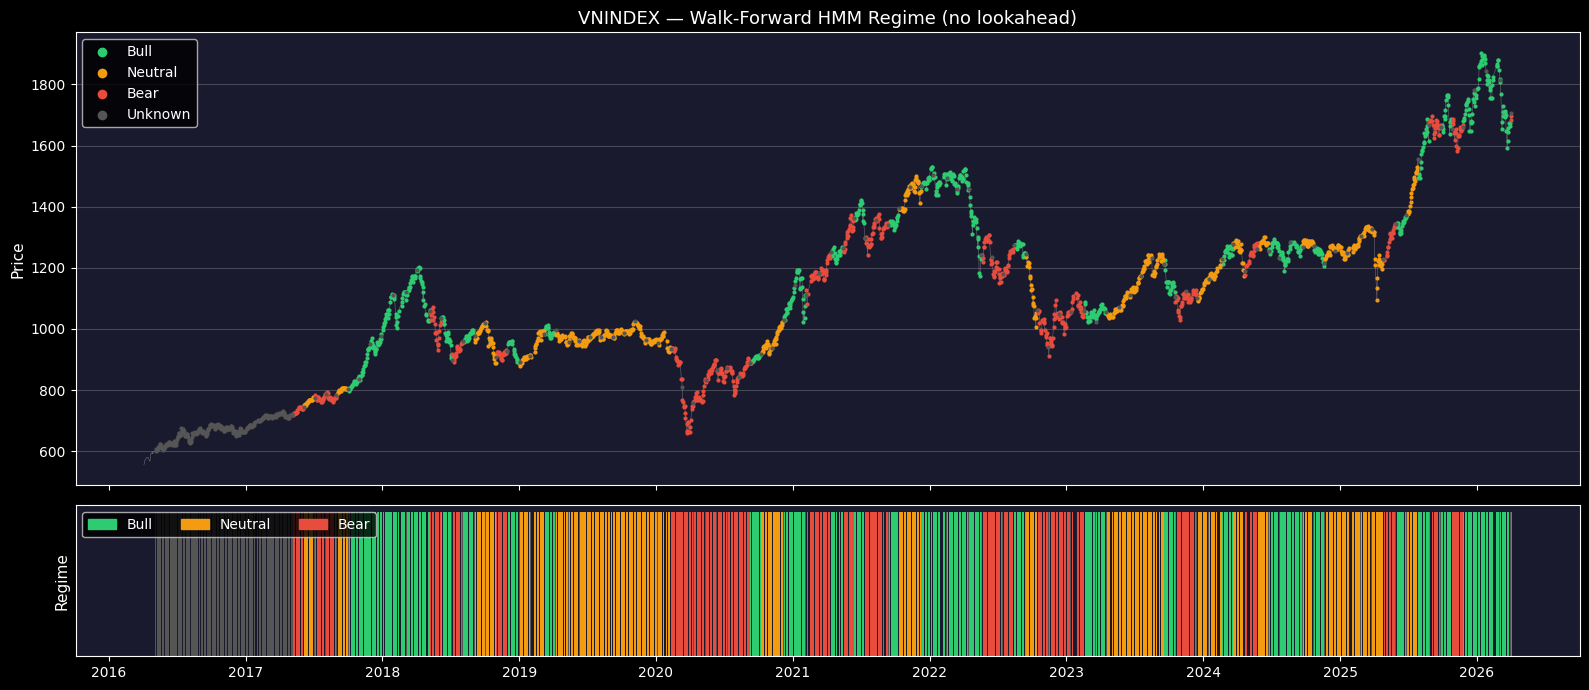

In [28]:
# ── visualise regime timeline on benchmark ────────────────────────────────────
COLOR = {'Bull': '#2ecc71', 'Neutral': '#f39c12', 'Bear': '#e74c3c', 'Unknown': '#555555'}

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# price + coloured scatter
ax = axes[0]
ax.set_facecolor('#1a1a2e')
common_idx = bm_close.index.intersection(regime_series.index)
for lbl, col in COLOR.items():
    mask = regime_series.reindex(common_idx) == lbl
    ax.scatter(common_idx[mask], bm_close.reindex(common_idx)[mask],
               s=4, c=col, label=lbl, zorder=3)
ax.plot(bm_close.index, bm_close.values, color='white', lw=0.4, alpha=0.35)
ax.set_ylabel('Price', fontsize=11)
ax.set_title(f'{BENCHMARK} — Walk-Forward HMM Regime (no lookahead)', fontsize=13)
ax.legend(loc='upper left', markerscale=3)
ax.yaxis.grid(True, alpha=0.2)

# regime bar
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_arr = [COLOR.get(r, '#555') for r in regime_series.reindex(common_idx)]
ax2.bar(common_idx, np.ones(len(common_idx)), color=colors_arr, width=1.5)
ax2.set_yticks([])
ax2.set_ylabel('Regime', fontsize=11)
patches = [mpatches.Patch(color=c, label=l) for l, c in COLOR.items() if l != 'Unknown']
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

## 3. Bollinger Squeeze + DeMarker Strategy (Baseline)

Exact same indicators and parameters as `backtest_001.ipynb`.

In [29]:
# ── Bollinger Squeeze + DeMarker indicator (Numba) ────────────────────────────
import numba as nb

@nb.njit(cache=True)
def bollinger_squeeze_demarker_nb(
    high_arr, low_arr, close_arr,
    demarker_period: int = 11,
    keltner_period:  int = 16,
    bb_period:       int = 15,
    bb_deviation:  float = 2.3,
    keltner_factor:float = 2.2,
):
    n = len(close_arr)
    # outputs
    squeeze_on = np.zeros(n, dtype=nb.boolean)
    direction  = np.zeros(n, dtype=nb.int64)

    for i in range(max(demarker_period, keltner_period, bb_period), n):
        # --- DeMarker ---
        dm_sum_high = 0.0
        dm_sum_low  = 0.0
        for j in range(i - demarker_period + 1, i + 1):
            dh = max(high_arr[j] - high_arr[j-1], 0.0)
            dl = max(low_arr[j-1]  - low_arr[j],   0.0)
            dm_sum_high += dh
            dm_sum_low  += dl
        denom = dm_sum_high + dm_sum_low
        dem   = dm_sum_high / denom if denom != 0.0 else 0.5

        # --- Bollinger Bands ---
        bb_slice = close_arr[i - bb_period + 1 : i + 1]
        bb_mean  = bb_slice.mean()
        bb_std   = bb_slice.std()
        bb_upper = bb_mean + bb_deviation * bb_std
        bb_lower = bb_mean - bb_deviation * bb_std
        bb_width = bb_upper - bb_lower

        # --- Keltner Channel (EMA approximation via SMA) ---
        kc_slice = close_arr[i - keltner_period + 1 : i + 1]
        kc_mean  = kc_slice.mean()
        atr_sum  = 0.0
        for j in range(i - keltner_period + 1, i + 1):
            atr_sum += max(high_arr[j], close_arr[j-1]) - min(low_arr[j], close_arr[j-1])
        atr_avg  = atr_sum / keltner_period
        kc_width = 2.0 * keltner_factor * atr_avg

        squeeze_on[i] = bb_width < kc_width
        direction[i]  = 1 if dem > 0.5 else -1

    return squeeze_on, direction

print('Numba indicator compiled')

Numba indicator compiled


In [30]:
# ── parameters (from backtest_001 optimised run) ──────────────────────────────
DEMARKER_PERIOD = 11
KELTNER_PERIOD  = 16
BB_PERIOD       = 15
BB_DEVIATION    = 2.3
KELTNER_FACTOR  = 2.2
ATR_PERIOD      = 10
ATR_MULTIPLIER  = 1.8
RVOL_PERIOD     = 10
RVOL_MIN        = 1.25
SL_STOP         = 0.10

# ── compute signals ───────────────────────────────────────────────────────────
squeeze_on_dict  = {}
direction_dict   = {}

for sym in valid_syms:
    h = high[sym].values
    l = low[sym].values
    c = close[sym].values
    sq, dr = bollinger_squeeze_demarker_nb(
        h, l, c,
        demarker_period=DEMARKER_PERIOD,
        keltner_period=KELTNER_PERIOD,
        bb_period=BB_PERIOD,
        bb_deviation=BB_DEVIATION,
        keltner_factor=KELTNER_FACTOR,
    )
    squeeze_on_dict[sym] = sq
    direction_dict[sym]  = dr

squeeze_on_df = pd.DataFrame(squeeze_on_dict, index=close.index)
direction_df  = pd.DataFrame(direction_dict,  index=close.index)

# RVOL (volume relative to prior N-day average, using prior bar to avoid lookahead)
vol_ma_prior = volume.shift(1).rolling(RVOL_PERIOD, min_periods=RVOL_PERIOD).mean()
rvol = volume / vol_ma_prior

# ATR trailing stop
atr_indicator = vbt.IndicatorFactory.from_talib('ATR').run(
    high, low, close, timeperiod=ATR_PERIOD
)
# shift ATR by 1 to use prior-bar ATR (no lookahead)
atr_scope = atr_indicator.real.shift(1)

ATRTrailing = vbt.IndicatorFactory(
    input_names=['close', 'atr'],
    param_names=['atr_multiplier'],
    output_names=['atr_trailing'],
).from_apply_func(atr_trailing_nb)

atr_sl = ATRTrailing.run(close, atr_scope, atr_multiplier=ATR_MULTIPLIER)

print('Signals computed')

Signals computed


In [31]:
# ── entry & exit signals ──────────────────────────────────────────────────────
# Entry: squeeze JUST turned off (was on yesterday, off today) AND bullish AND volume confirms
squeeze_released = squeeze_on_df.shift(1).fillna(False) & ~squeeze_on_df
bullish          = direction_df == 1
# vol_ok           = rvol >= RVOL_MIN

entries_base = squeeze_released & bullish

# Exit: price crosses below ATR trailing stop
exits = close.vbt.crossed_below(atr_sl.atr_trailing)

print(f'Total entry signals (baseline): {entries_base.sum().sum():,}')

Total entry signals (baseline): 9,157


## 4. Apply HMM Regime Filter

In [32]:
# ── build regime mask (True = allowed to enter) ───────────────────────────────
# Align regime_series to the close price index
regime_aligned = regime_series.reindex(close.index)

# Strategy A: allow Bull + Neutral  (block Bear)
allowed_bullneutral = regime_aligned.isin(['Bull', 'Neutral'])

# Strategy B: allow Bull only  (most conservative)
allowed_bull_only   = regime_aligned == 'Bull'

# Broadcast to all symbols (same regime for each symbol — index-level)
# shape: (n_dates,) → (n_dates, n_symbols)
def broadcast_mask(series_mask, columns):
    df = pd.DataFrame(
        np.tile(series_mask.values.reshape(-1, 1), (1, len(columns))),
        index=series_mask.index,
        columns=columns,
    )
    return df

mask_bullneutral = broadcast_mask(allowed_bullneutral, valid_syms)
mask_bull_only   = broadcast_mask(allowed_bull_only,   valid_syms)

# Filtered entries
entries_bullneutral = entries_base & mask_bullneutral
entries_bull_only   = entries_base & mask_bull_only

# Unknown regime (burn-in period) — treat as allowed in baseline, blocked in filtered
# (conservative choice for the filtered version)

print(f'Entry signals — Baseline:       {entries_base.sum().sum():,}')
print(f'Entry signals — Bull+Neutral:   {entries_bullneutral.sum().sum():,}')
print(f'Entry signals — Bull only:      {entries_bull_only.sum().sum():,}')

Entry signals — Baseline:       9,157
Entry signals — Bull+Neutral:   5,559
Entry signals — Bull only:      2,679


## 5. Backtest — Baseline vs Regime-Filtered

In [33]:
COMMON_KWARGS = dict(
    freq        = '1d',
    group_by    = False,          # per-symbol for stats
    cash_sharing= False,
    sl_stop     = SL_STOP,
    init_cash   = 100,
)

print('Running backtest — Baseline …')
pf_base = vbt.Portfolio.from_signals(
    close=close, entries=entries_base, exits=exits, **COMMON_KWARGS
)

print('Running backtest — Bull+Neutral …')
pf_bn = vbt.Portfolio.from_signals(
    close=close, entries=entries_bullneutral, exits=exits, **COMMON_KWARGS
)

print('Running backtest — Bull only …')
pf_bull = vbt.Portfolio.from_signals(
    close=close, entries=entries_bull_only, exits=exits, **COMMON_KWARGS
)

print('Done.')

Running backtest — Baseline …
Running backtest — Bull+Neutral …
Running backtest — Bull only …
Done.


## 6. Results Comparison

In [34]:
def portfolio_summary(pf, name):
    """Aggregate stats across all symbols."""
    sharpe    = pf.sharpe_ratio()
    sortino   = pf.sortino_ratio()
    total_ret = pf.total_return()
    max_dd    = pf.max_drawdown()
    n_trades  = pf.trades.count()
    win_rate  = pf.trades.win_rate()

    return pd.Series({
        'Portfolio':       name,
        'Sharpe (mean)':   sharpe.mean().round(3),
        'Sharpe (median)': sharpe.median().round(3),
        'Sharpe > 1.0':    f"{(sharpe > 1.0).sum()}/{len(sharpe)}",
        'Sortino (mean)':  sortino.mean().round(3),
        'Total Ret (mean)':f"{total_ret.mean():.1%}",
        'Max DD (mean)':   f"{max_dd.mean():.1%}",
        'N Trades':        int(n_trades.sum()),
        'Win Rate':        f"{win_rate.mean():.1%}",
    })

summary = pd.DataFrame([
    portfolio_summary(pf_base, 'Baseline'),
    portfolio_summary(pf_bn,   'HMM Bull+Neutral'),
    portfolio_summary(pf_bull, 'HMM Bull Only'),
]).set_index('Portfolio')

print('\n=== Strategy Comparison ===')
display(summary)


=== Strategy Comparison ===


,Sharpe (mean),Sharpe (median),Sharpe > 1.0,Sortino (mean),Total Ret (mean),Max DD (mean),N Trades,Win Rate
Portfolio,,,,,,,,
Baseline,0.482,0.498,22/198,0.776,144.1%,-36.6%,7039,41.1%
HMM Bull+Neutral,0.316,0.304,7/198,0.519,57.4%,-32.4%,4478,39.2%
HMM Bull Only,0.093,0.099,3/198,0.188,15.0%,-28.8%,2335,35.8%


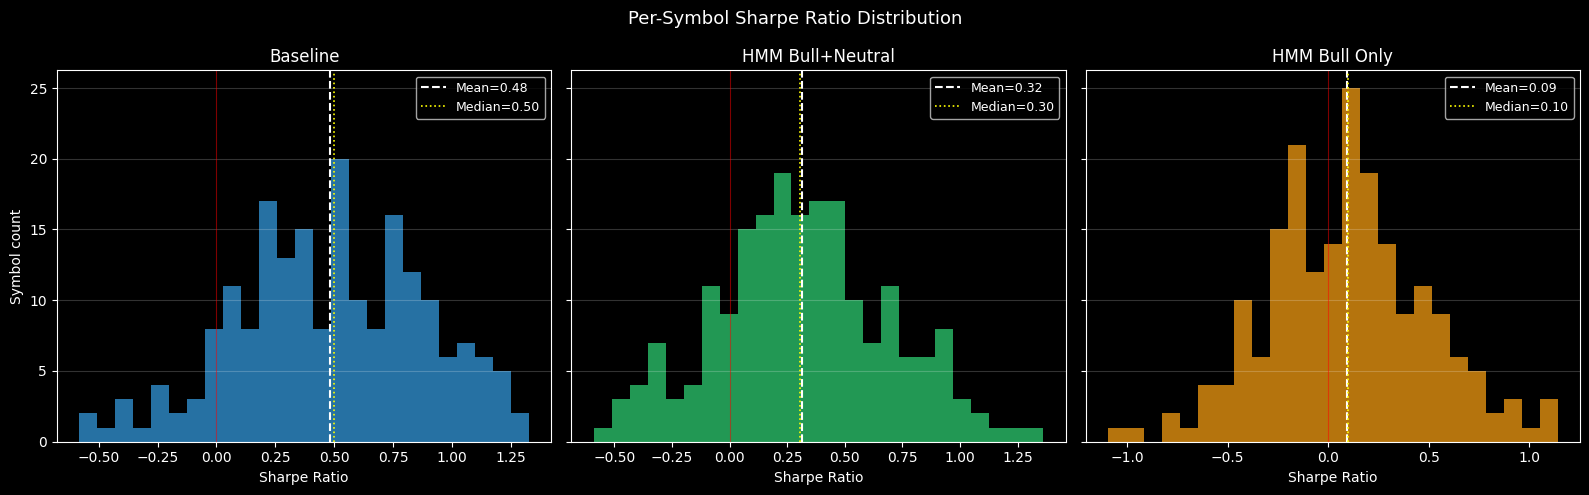

In [35]:
# ── Sharpe distribution plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

portfolios = [
    (pf_base, 'Baseline',         '#3498db'),
    (pf_bn,   'HMM Bull+Neutral', '#2ecc71'),
    (pf_bull, 'HMM Bull Only',    '#f39c12'),
]

for ax, (pf, name, col) in zip(axes, portfolios):
    sharpe_vals = pf.sharpe_ratio().dropna()
    ax.hist(sharpe_vals, bins=25, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sharpe_vals.mean(),   color='white', lw=1.5, ls='--', label=f'Mean={sharpe_vals.mean():.2f}')
    ax.axvline(sharpe_vals.median(), color='yellow', lw=1.2, ls=':', label=f'Median={sharpe_vals.median():.2f}')
    ax.axvline(0, color='red', lw=0.8, alpha=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Sharpe Ratio')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Ratio Distribution', fontsize=13)
fig.tight_layout()
plt.show()

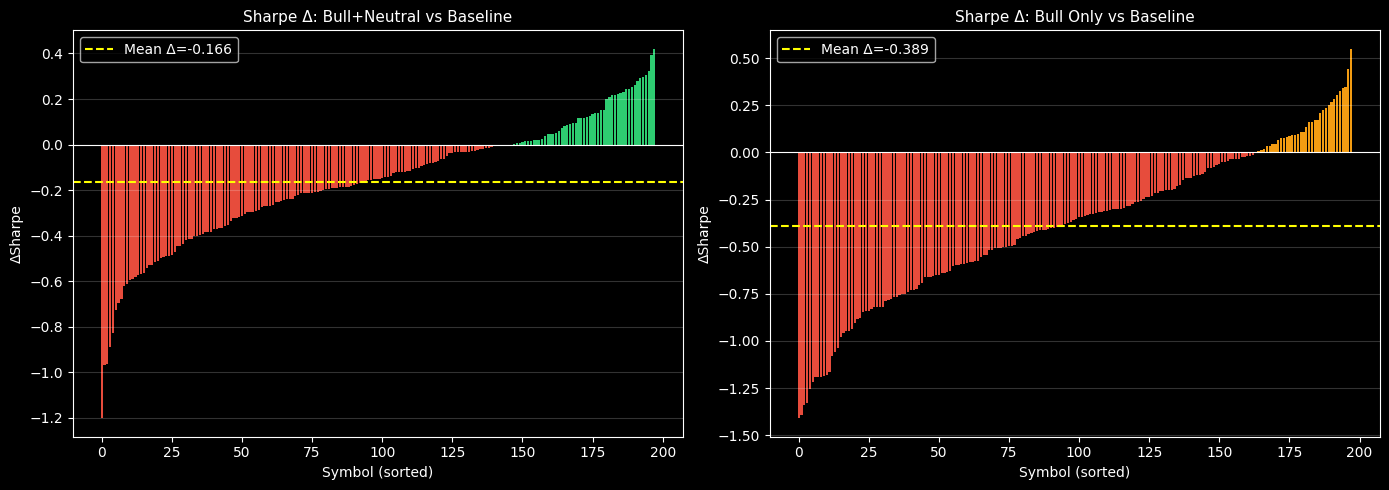


Bull+Neutral — improved: 51/198  mean Δ=-0.166
Bull Only    — improved: 34/198  mean Δ=-0.389


In [36]:
# ── per-symbol Sharpe delta: Regime vs Baseline ───────────────────────────────
sharpe_base = pf_base.sharpe_ratio().rename('Baseline')
sharpe_bn   = pf_bn.sharpe_ratio().rename('Bull+Neutral')
sharpe_bull = pf_bull.sharpe_ratio().rename('Bull Only')

delta_bn   = (sharpe_bn   - sharpe_base).dropna().rename('Δ Bull+Neutral')
delta_bull = (sharpe_bull - sharpe_base).dropna().rename('Δ Bull Only')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, delta, col, name in [
    (axes[0], delta_bn,   '#2ecc71', 'Bull+Neutral vs Baseline'),
    (axes[1], delta_bull, '#f39c12', 'Bull Only vs Baseline'),
]:
    ax.bar(range(len(delta)), delta.sort_values(),
           color=[col if v >= 0 else '#e74c3c' for v in delta.sort_values()])
    ax.axhline(0, color='white', lw=0.8)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    ax.set_title(f'Sharpe Δ: {name}', fontsize=11)
    ax.set_xlabel('Symbol (sorted)')
    ax.set_ylabel('ΔSharpe')
    ax.legend()
    ax.yaxis.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

print(f'\nBull+Neutral — improved: {(delta_bn > 0).sum()}/{len(delta_bn)}  mean Δ={delta_bn.mean():+.3f}')
print(f'Bull Only    — improved: {(delta_bull > 0).sum()}/{len(delta_bull)}  mean Δ={delta_bull.mean():+.3f}')

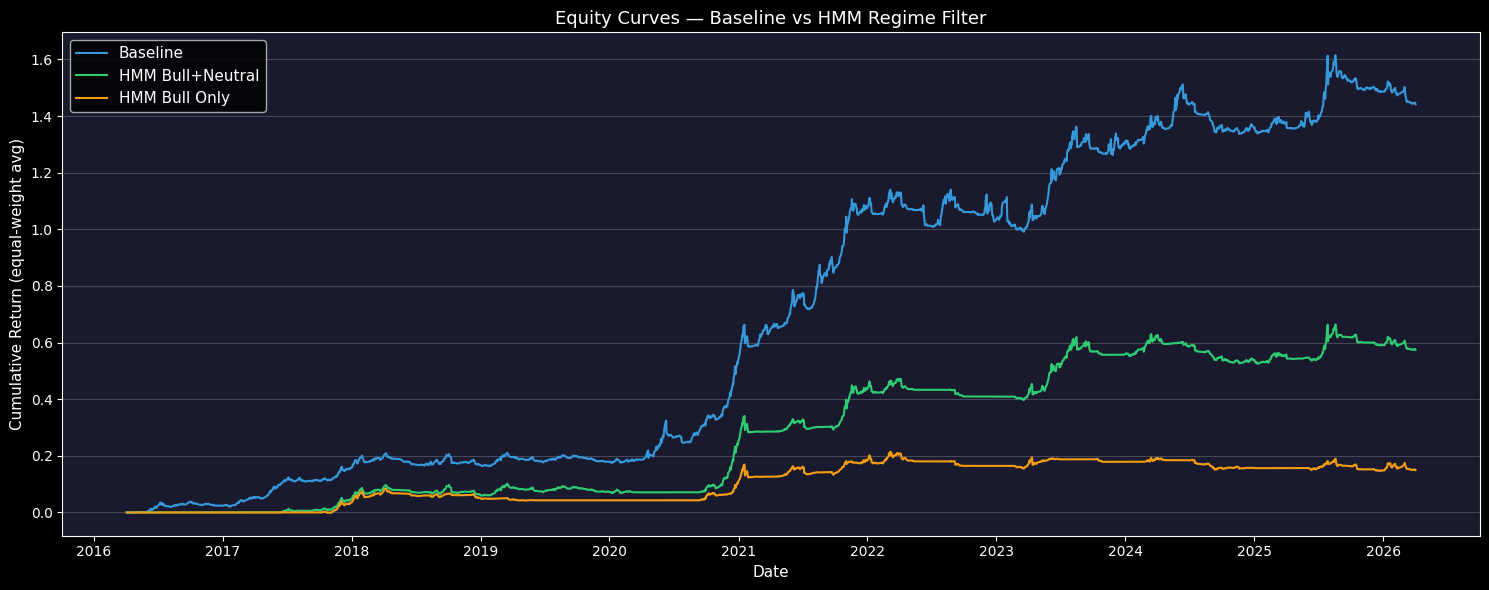

In [37]:
# ── cumulative equity curves (portfolio-level, equal-weight) ──────────────────
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

curves = [
    (pf_base, 'Baseline',         '#3498db'),
    (pf_bn,   'HMM Bull+Neutral', '#2ecc71'),
    (pf_bull, 'HMM Bull Only',    '#f39c12'),
]

for pf, name, col in curves:
    # equal-weight cumulative return across symbols
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=name, color=col, lw=1.5)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Equity Curves — Baseline vs HMM Regime Filter', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

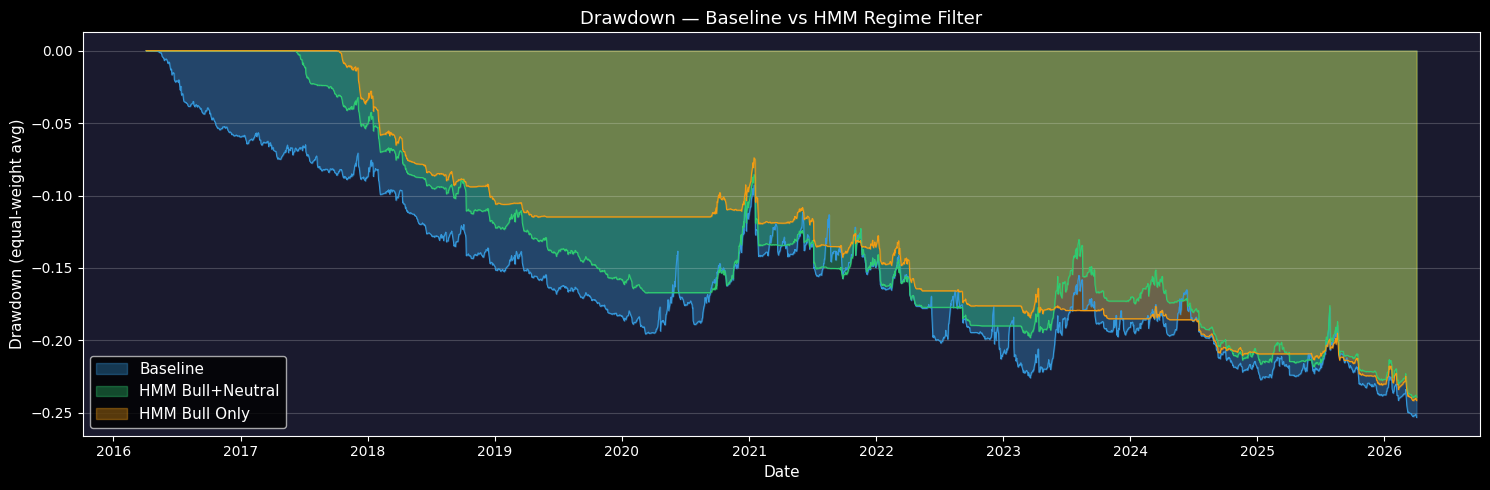

In [38]:
# ── drawdown comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_facecolor('#1a1a2e')

for pf, name, col in curves:
    dd = pf.drawdown().mean(axis=1)
    ax.fill_between(dd.index, dd.values, 0, alpha=0.35, color=col, label=name)
    ax.plot(dd.index, dd.values, color=col, lw=0.8)

ax.set_ylabel('Drawdown (equal-weight avg)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Drawdown — Baseline vs HMM Regime Filter', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

In [39]:
# ── detailed stats table ──────────────────────────────────────────────────────
def full_stats(pf, name):
    s = pf.sharpe_ratio()
    return pd.Series({
        'Name':             name,
        'Sharpe mean':      s.mean().round(3),
        'Sharpe median':    s.median().round(3),
        'Sharpe std':       s.std().round(3),
        'Sharpe > 0':       f"{(s > 0).sum()}/{len(s)}",
        'Sharpe > 1':       f"{(s > 1).sum()}/{len(s)}",
        'Sortino mean':     pf.sortino_ratio().mean().round(3),
        'Calmar mean':      pf.calmar_ratio().mean().round(3),
        'Total Ret mean':   f"{pf.total_return().mean():.1%}",
        'Total Ret median': f"{pf.total_return().median():.1%}",
        'Max DD mean':      f"{pf.max_drawdown().mean():.1%}",
        'Max DD worst':     f"{pf.max_drawdown().min():.1%}",
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f"{pd.Series(pf.trades.returns.mean()).mean():.2%}",
        'Win Rate':         f"{pf.trades.win_rate().mean():.1%}",
        'Profit Factor':    pf.trades.profit_factor().mean().round(3),
    })

full_table = pd.DataFrame([
    full_stats(pf_base, 'Baseline'),
    full_stats(pf_bn,   'HMM Bull+Neutral'),
    full_stats(pf_bull, 'HMM Bull Only'),
]).set_index('Name')

print('=== Full Statistics ===')
display(full_table.T)

=== Full Statistics ===


Name,Baseline,HMM Bull+Neutral,HMM Bull Only
Sharpe mean,0.482,0.316,0.093
Sharpe median,0.498,0.304,0.099
Sharpe std,0.4,0.374,0.396
Sharpe > 0,177/198,161/198,117/198
Sharpe > 1,22/198,7/198,3/198
Sortino mean,0.776,0.519,0.188
Calmar mean,0.317,0.189,0.066
Total Ret mean,144.1%,57.4%,15.0%
Total Ret median,70.4%,27.4%,3.2%
Max DD mean,-36.6%,-32.4%,-28.8%


## 7. Regime Filter Impact Analysis

In [40]:
# ── trade win-rate by regime at entry ─────────────────────────────────────────
# For each trade in the baseline, look up the regime on entry date
trades_base = pf_base.trades.records_readable
trades_base = trades_base.copy()

# Map entry date → regime label (vectorbt uses 'Entry Timestamp' when entry_idx maps to index)
_entry_col = next((c for c in ('Entry Timestamp', 'Entry Index') if c in trades_base.columns), None)
if _entry_col is None:
    raise KeyError(f"No entry time column; columns={list(trades_base.columns)}")
trades_base['entry_regime'] = trades_base[_entry_col].map(regime_aligned).fillna('Unknown')

regime_trade_stats = (
    trades_base
    .groupby('entry_regime')
    .agg(
        n_trades    = ('Return', 'count'),
        win_rate    = ('Return', lambda x: (x > 0).mean()),
        avg_ret     = ('Return', 'mean'),
        median_ret  = ('Return', 'median'),
        sharpe_like = ('Return', lambda x: x.mean() / x.std() if x.std() > 0 else 0),
    )
    .round(4)
)

print('Trade statistics by regime at entry date:')
display(regime_trade_stats)

Trade statistics by regime at entry date:


,n_trades,win_rate,avg_ret,median_ret,sharpe_like
entry_regime,,,,,
Bear,2033,0.4629,0.0343,-0.0054,0.2107
Bull,2011,0.3441,0.0078,-0.0276,0.0642
Neutral,2164,0.4261,0.0344,-0.0118,0.2190
Unknown,831,0.4284,0.0272,-0.0126,0.1981


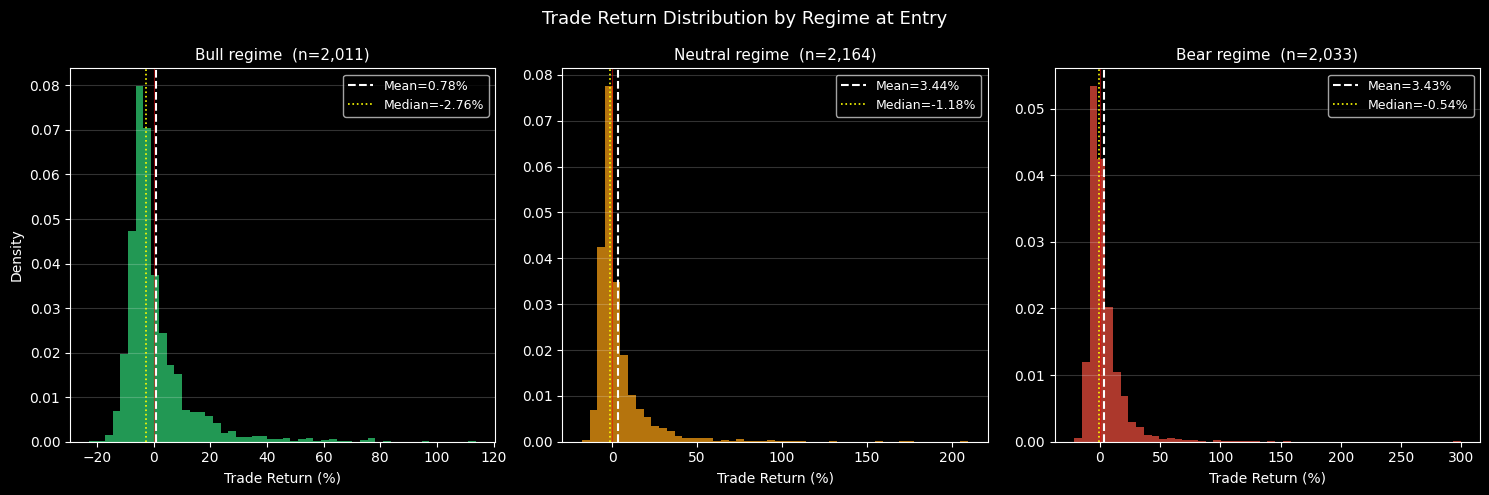

In [41]:
# ── return distribution by regime at entry ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

regime_colors = {'Bull': '#2ecc71', 'Neutral': '#f39c12', 'Bear': '#e74c3c'}

for ax, (regime, col) in zip(axes, regime_colors.items()):
    sub = trades_base.loc[trades_base['entry_regime'] == regime, 'Return'] * 100
    if len(sub) == 0:
        ax.set_title(f'{regime} (no trades)')
        continue
    ax.hist(sub, bins=50, color=col, alpha=0.75, edgecolor='none', density=True)
    ax.axvline(sub.mean(),   color='white',  lw=1.5, ls='--', label=f'Mean={sub.mean():.2f}%')
    ax.axvline(sub.median(), color='yellow', lw=1.2, ls=':',  label=f'Median={sub.median():.2f}%')
    ax.axvline(0, color='red', lw=0.8, alpha=0.5)
    ax.set_title(f'{regime} regime  (n={len(sub):,})', fontsize=11)
    ax.set_xlabel('Trade Return (%)')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Density')
fig.suptitle('Trade Return Distribution by Regime at Entry', fontsize=13)
fig.tight_layout()
plt.show()

In [42]:
# ── final verdict ─────────────────────────────────────────────────────────────
s_base = pf_base.sharpe_ratio().mean()
s_bn   = pf_bn.sharpe_ratio().mean()
s_bull = pf_bull.sharpe_ratio().mean()

print('=' * 55)
print('  SHARPE RATIO SUMMARY (mean across all symbols)')
print('=' * 55)
print(f'  Baseline            : {s_base:.3f}')
print(f'  HMM Bull+Neutral    : {s_bn:.3f}  ({s_bn-s_base:+.3f})')
print(f'  HMM Bull Only       : {s_bull:.3f}  ({s_bull-s_base:+.3f})')
print('=' * 55)

best = max([(s_base, 'Baseline'), (s_bn, 'Bull+Neutral'), (s_bull, 'Bull Only')], key=lambda x: x[0])
print(f'\n  Best: {best[1]} (Sharpe={best[0]:.3f})')

  SHARPE RATIO SUMMARY (mean across all symbols)
  Baseline            : 0.482
  HMM Bull+Neutral    : 0.316  (-0.166)
  HMM Bull Only       : 0.093  (-0.389)

  Best: Baseline (Sharpe=0.482)


## 8. Option A — Position Sizing by Regime

Instead of blocking Bear trades, we **scale the number of shares purchased**
based on regime at entry time:

| Regime | Budget fraction | Shares bought |
|--------|----------------|---------------|
| Bull | 100% of `INIT_CASH` | `INIT_CASH / price` |
| Neutral | 50% of `INIT_CASH` | `0.5 * INIT_CASH / price` |
| Bear | 25% of `INIT_CASH` | `0.25 * INIT_CASH / price` |

All entry signals still fire — only size per trade changes.

In [48]:
# ── regime → fraction of INIT_CASH invested per trade ───────────────────────
INIT_CASH = 100   # matches the backtest init_cash

SIZING_MAP = {'Bull': 1.0, 'Neutral': 0.5, 'Bear': 0.25, 'Unknown': 1.0}

size_frac = regime_aligned.map(SIZING_MAP).fillna(1.0)

# Broadcast to all symbols
size_frac_df = pd.DataFrame(
    np.tile(size_frac.values.reshape(-1, 1), (1, len(valid_syms))),
    index=size_frac.index,
    columns=valid_syms,
)

# Convert fraction → number of shares at each bar's close price
# share_size[t, sym] = how many shares to buy if entry fires on bar t
budget_df    = size_frac_df * INIT_CASH          # dollar budget per trade
share_size_df = (budget_df / close).fillna(0)     # shares = budget / price
share_size_df = share_size_df.replace([np.inf, -np.inf], 0)

# ── sanity check: spot-check a few entry dates ────────────────────────────────
sample_entries = entries_base.stack()
sample_entries = sample_entries[sample_entries].reset_index()
sample_entries.columns = ['date', 'symbol', 'entry']
sample_entries['regime']  = sample_entries['date'].map(regime_aligned)
sample_entries['fraction'] = sample_entries['date'].map(size_frac)
sample_entries['close_px'] = sample_entries.apply(
    lambda r: close.loc[r['date'], r['symbol']] if r['symbol'] in close.columns else np.nan, axis=1)
sample_entries['shares_bought'] = sample_entries.apply(
    lambda r: share_size_df.loc[r['date'], r['symbol']] if r['symbol'] in share_size_df.columns else np.nan, axis=1)

print('Sample entry sizing:')
display(sample_entries.dropna().head(12).to_string(index=False))
print()
print('Mean shares by regime:')
print(sample_entries.groupby('regime')['shares_bought'].mean().round(4))


Sample entry sizing:


'      date symbol  entry  regime  fraction  close_px  shares_bought\n2016-05-05    DRC   True Unknown       1.0 20.767267       4.815270\n2016-05-05    NHA   True Unknown       1.0  2.688517      37.195222\n2016-05-05    NLG   True Unknown       1.0 11.638953       8.591838\n2016-05-06    HBC   True Unknown       1.0  6.131590      16.308983\n2016-05-06    MWG   True Unknown       1.0  9.054063      11.044765\n2016-05-06    TNG   True Unknown       1.0  5.393080      18.542279\n2016-05-09    PVT   True Unknown       1.0  4.400000      22.727272\n2016-05-10    SJS   True Unknown       1.0  6.750000      14.814815\n2016-05-11    CTG   True Unknown       1.0  7.650000      13.071895\n2016-05-11    HBC   True Unknown       1.0  6.131590      16.308983\n2016-05-12    VNM   True Unknown       1.0 56.046238       1.784241\n2016-05-13    CTD   True Unknown       1.0 80.019997       1.249688'


Mean shares by regime:
regime
Bear        2.1723
Bull        7.1147
Neutral     4.0505
Unknown    12.1316
Name: shares_bought, dtype: float64


In [49]:
# ── backtest with position sizing (size = number of shares, default size_type) ─
print('Running Option A (position sizing) …')
pf_sizing = vbt.Portfolio.from_signals(
    close        = close,
    entries      = entries_base,
    exits        = exits,
    size         = share_size_df,   # number of shares — varies by regime
    freq         = '1d',
    group_by     = False,
    cash_sharing = False,
    sl_stop      = SL_STOP,
    init_cash    = INIT_CASH,
)
print('Done.')

s_sizing = pf_sizing.sharpe_ratio().mean()
print(f'\nSharpe — Baseline     : {s_base:.3f}')
print(f'Sharpe — Option A     : {s_sizing:.3f}  ({s_sizing - s_base:+.3f})')


Running Option A (position sizing) …
Done.

Sharpe — Baseline     : 0.482
Sharpe — Option A     : 0.415  (-0.067)


In [45]:
# ── Option A detailed stats ───────────────────────────────────────────────────
summary_a = pd.DataFrame([
    full_stats(pf_base,   'Baseline'),
    full_stats(pf_sizing, 'Option A: Position Sizing'),
]).set_index('Name')
display(summary_a.T)


Name,Baseline,Option A: Position Sizing
Sharpe mean,0.482,0.415
Sharpe median,0.498,0.423
Sharpe std,0.4,0.391
Sharpe > 0,177/198,171/198
Sharpe > 1,22/198,10/198
Sortino mean,0.776,0.693
Calmar mean,0.317,0.272
Total Ret mean,144.1%,46.5%
Total Ret median,70.4%,35.6%
Max DD mean,-36.6%,-24.6%


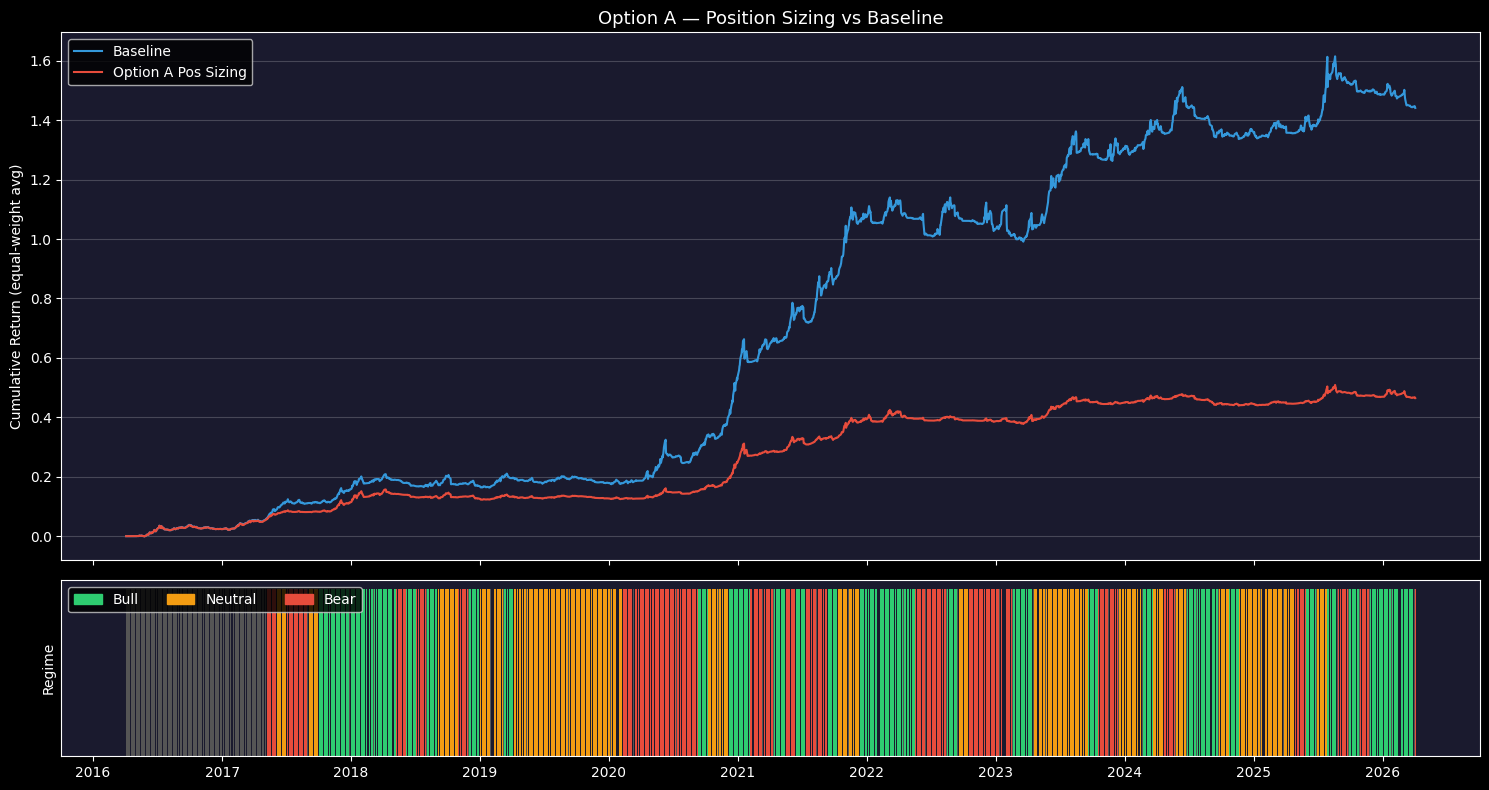

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.set_facecolor('#1a1a2e')
for pf, name, col in [
    (pf_base,   'Baseline',            '#3498db'),
    (pf_sizing, 'Option A Pos Sizing', '#e74c3c'),
]:
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=name, lw=1.5, color=col)
ax.set_ylabel('Cumulative Return (equal-weight avg)')
ax.set_title('Option A — Position Sizing vs Baseline', fontsize=13)
ax.legend(); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_regime = [COLOR.get(r, '#555') for r in regime_aligned.reindex(close.index)]
ax2.bar(close.index, np.ones(len(close)), color=colors_regime, width=1.5)
ax2.set_yticks([]); ax2.set_ylabel('Regime')
patches = [mpatches.Patch(color=c, label=l) for l, c in COLOR.items() if l != 'Unknown']
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout(); plt.show()


## 9. Option B — 2-State HMM (Risk-On / Risk-Off) + Weekly Retraining

Two changes vs the original 3-state monthly model:
1. **`n_components=2`** — simpler Risk-On / Risk-Off; less over-segmentation
2. **`retrain_every=5`** (weekly) — reduces regime lag from ~21 days to ~5 days

**B1**: binary entry block (no entries during Risk-Off)  
**B2**: position sizing (Risk-On = 100%, Risk-Off = 25% of budget)

In [50]:
# ── walk-forward 2-state HMM, weekly retraining ───────────────────────────────
print('Running 2-state walk-forward HMM (weekly retraining) …')
regime_2state = build_wf_regime(
    feat_bm,
    FEATURE_COLS,
    n_components  = 2,
    burn_in       = BURN_IN_DAYS,
    retrain_every = 5,
    random_seed   = RANDOM_SEED,
)
print('Done.')

# Map labels: Bull→Risk-On, Bear→Risk-Off, Neutral→Risk-On (only 2 states so Neutral absent)
regime_2state = regime_2state.replace({'Bull': 'Risk-On', 'Neutral': 'Risk-On', 'Bear': 'Risk-Off'})
regime_2_aligned = regime_2state.reindex(close.index)

print('\nRegime distribution:')
print(regime_2state.value_counts())


Running 2-state walk-forward HMM (weekly retraining) …


IndexError: list index out of range

In [ ]:
COLOR2 = {'Risk-On': '#2ecc71', 'Risk-Off': '#e74c3c', 'Unknown': '#555555'}

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax = axes[0]; ax.set_facecolor('#1a1a2e')
common = bm_close.index.intersection(regime_2state.index)
for lbl, col in COLOR2.items():
    mask = regime_2state.reindex(common) == lbl
    ax.scatter(common[mask], bm_close.reindex(common)[mask], s=4, c=col, label=lbl, zorder=3)
ax.plot(bm_close.index, bm_close.values, color='white', lw=0.4, alpha=0.35)
ax.set_ylabel('Price'); ax.set_title(f'{BENCHMARK} — 2-State HMM (weekly)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
c2 = [COLOR2.get(r, '#555') for r in regime_2state.reindex(common)]
ax2.bar(common, np.ones(len(common)), color=c2, width=1.5); ax2.set_yticks([])
ax2.set_ylabel('Regime')
patches2 = [mpatches.Patch(color=c, label=l) for l, c in COLOR2.items() if l != 'Unknown']
ax2.legend(handles=patches2, loc='upper left', ncol=2)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


In [ ]:
# ── Option B1: binary block Risk-Off entries ─────────────────────────────────
mask_risk_on = broadcast_mask(regime_2_aligned == 'Risk-On', valid_syms)
entries_b1   = entries_base & mask_risk_on

# ── Option B2: position sizing via 2-state regime ────────────────────────────
SIZING_2STATE = {'Risk-On': 1.0, 'Risk-Off': 0.25, 'Unknown': 1.0}
size_frac_2   = regime_2_aligned.map(SIZING_2STATE).fillna(1.0)
size_frac_2_df = pd.DataFrame(
    np.tile(size_frac_2.values.reshape(-1, 1), (1, len(valid_syms))),
    index=size_frac_2.index, columns=valid_syms,
)
share_size_2_df = (size_frac_2_df * INIT_CASH / close).fillna(0)
share_size_2_df = share_size_2_df.replace([np.inf, -np.inf], 0)

print('Running Option B1 (2-state binary filter) …')
pf_b1 = vbt.Portfolio.from_signals(
    close=close, entries=entries_b1, exits=exits,
    freq='1d', group_by=False, cash_sharing=False,
    sl_stop=SL_STOP, init_cash=INIT_CASH,
)

print('Running Option B2 (2-state position sizing) …')
pf_b2 = vbt.Portfolio.from_signals(
    close=close, entries=entries_base, exits=exits,
    size=share_size_2_df,
    freq='1d', group_by=False, cash_sharing=False,
    sl_stop=SL_STOP, init_cash=INIT_CASH,
)

print('Done.')
for name, pf in [('B1 binary', pf_b1), ('B2 pos sizing', pf_b2)]:
    s = pf.sharpe_ratio().mean()
    print(f'  Option {name}: Sharpe={s:.3f}  ({s - s_base:+.3f} vs baseline)')


## 10. Full Comparison — All Variants

In [ ]:
comparison = pd.DataFrame([
    full_stats(pf_base,   'Baseline'),
    full_stats(pf_bn,     '3-state BN binary (original)'),
    full_stats(pf_sizing, 'Option A: 3-state pos sizing'),
    full_stats(pf_b1,     'Option B1: 2-state binary'),
    full_stats(pf_b2,     'Option B2: 2-state pos sizing'),
]).set_index('Name')

print('=== ALL VARIANTS ===')
display(comparison.T)


In [ ]:
portfolios_all = [
    (pf_base,   'Baseline',              '#95a5a6'),
    (pf_bn,     '3-state BN binary',     '#e74c3c'),
    (pf_sizing, 'Option A pos sizing',   '#3498db'),
    (pf_b1,     'Option B1 binary',      '#27ae60'),
    (pf_b2,     'Option B2 pos sizing',  '#2ecc71'),
]

names   = [n for _, n, _ in portfolios_all]
sharpes = [pf.sharpe_ratio().mean() for pf, _, _ in portfolios_all]
colors  = [c for _, _, c in portfolios_all]

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#1a1a2e')
bars = ax.bar(names, sharpes, color=colors, edgecolor='none')
ax.axhline(sharpes[0], ls='--', color='white', lw=1, alpha=0.5, label='Baseline')
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, color='white')
ax.set_ylabel('Mean Sharpe Ratio (across all symbols)')
ax.set_title('Regime Integration — All Variants Compared', fontsize=13)
ax.tick_params(axis='x', rotation=20); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()

best_idx = int(np.argmax(sharpes))
print(f'\nBest: {names[best_idx]}  Sharpe={sharpes[best_idx]:.3f}  Δ={sharpes[best_idx]-sharpes[0]:+.3f}')
